# Import bibliotek

In [16]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
#import openxls

In [17]:
filename = "5_TurysciZagraniczniWgKrajow_powPoznanski_2016-2025_Gminy_DLUGIE.xlsx"
df = pd.read_excel("data\\" + filename, sheet_name="DANE")

In [18]:
df["Kod"] = df["Kod"].astype(str).str.zfill(7)

df["woj"] = df["Kod"].astype(str).str.slice(0, 2)
df["pow"] = df["Kod"].astype(str).str.slice(0, 4)
df["gm"]  = df["Kod"].astype(str).str.slice(0, 6)
df["rodzaj"] = df["Kod"].astype(str).str.slice(5, 6)

In [19]:
wojewodztwa = {
    "02": "Dolnośląskie",
    "04": "Kujawsko-Pomorskie",
    "06": "Lubelskie",
    "08": "Lubuskie",
    "10": "Łódzkie",
    "12": "Małopolskie",
    "14": "Mazowieckie",
    "16": "Opolskie",
    "18": "Podkarpackie",
    "20": "Podlaskie",
    "22": "Pomorskie",
    "24": "Śląskie",
    "26": "Świętokrzyskie",
    "28": "Warmińsko-Mazurskie",
    "30": "Wielkopolskie",
    "32": "Zachodniopomorskie"
}

In [20]:
df["wojewodztwo"] = df["woj"].map(wojewodztwa)

In [21]:
print((df["Kod"][0]))

3021011


In [ ]:
filename = filename.replace(".xlsx", "_mod.xlsx")

with pd.ExcelWriter("data\\" + filename) as writer:
    df.to_excel(writer, index=False)

# Wstępne wykresy

In [13]:
df_kornik = df[df["Kod"]==3021093].sort_values("Wartosc", ascending=False)

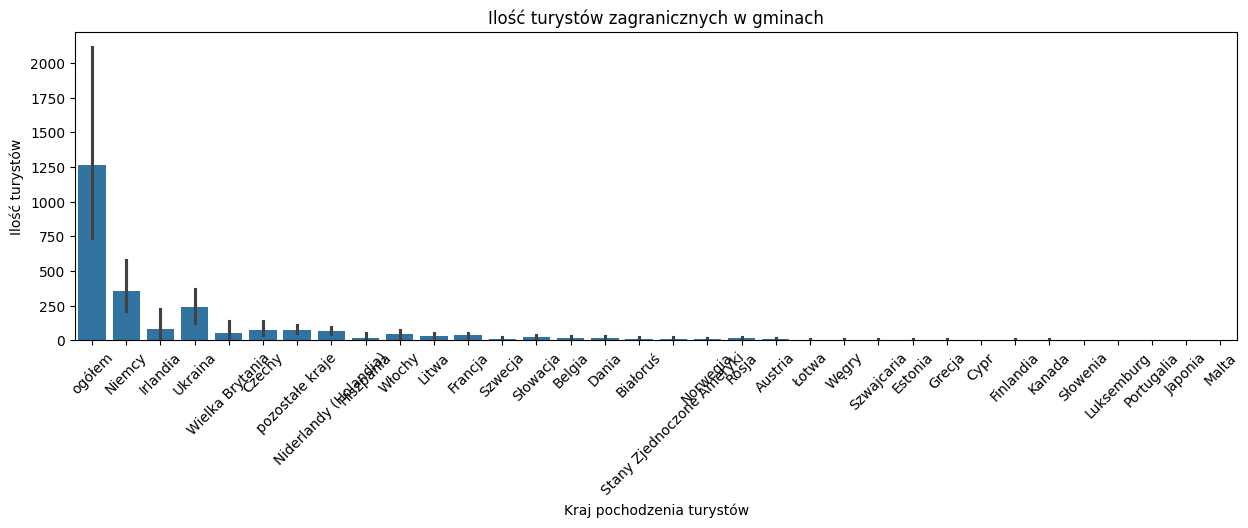

In [14]:
plt.figure(figsize=(15,4))
sns.barplot(
    data = df_kornik,
    y= "Wartosc",
    x="Kraje"
    )

plt.xlabel("Kraj pochodzenia turystów")
plt.ylabel("Ilość turystów")
plt.title("Ilość turystów zagranicznych w gminach")

plt.xticks(rotation = 45)

plt.show()


In [16]:
df_all = df[df["Kraje"]=="ogółem"]

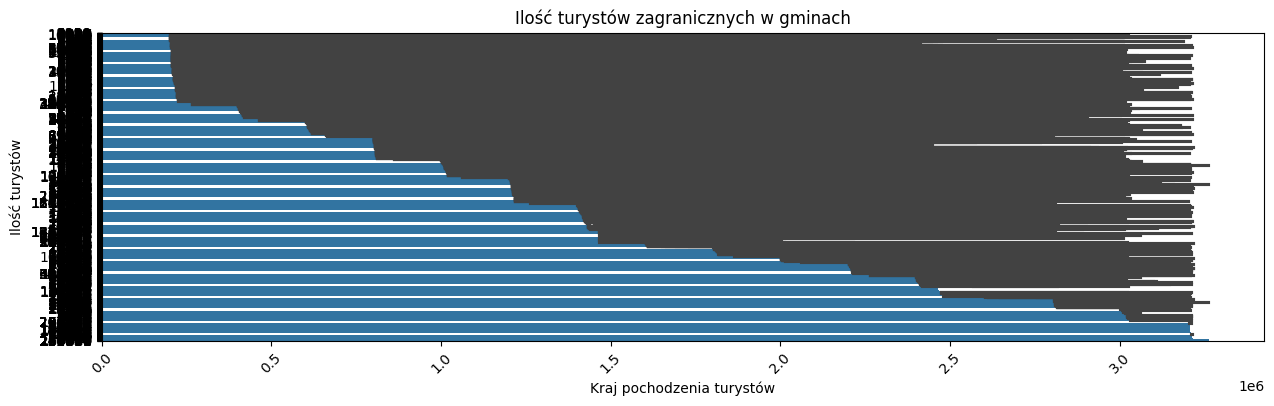

In [ ]:
plt.figure(figsize=(15,4))
sns.barplot(
    data = df_all,
    y= "Wartosc",
    x="Nazwa"
    )

plt.xlabel("Kraj pochodzenia turystów")
plt.ylabel("Ilość turystów")
plt.title("Ilość turystów zagranicznych w gminach")

plt.xticks(rotation = 45)

plt.show()

## Powiat poznański

In [33]:
df_poznan = df[df["pow"]=="3021"]

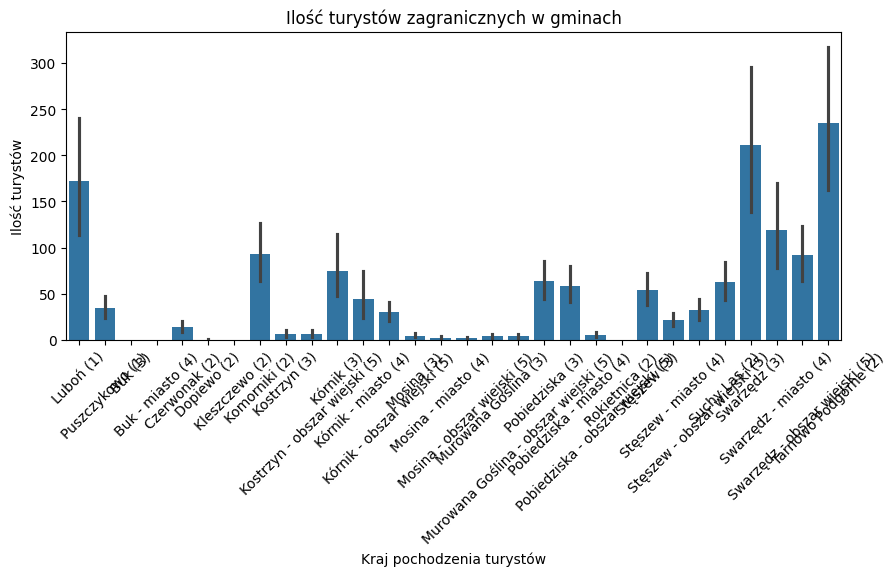

In [34]:
plt.figure(figsize=(10,4))
sns.barplot(
    data = df_poznan,
    y= "Wartosc",
    x="Nazwa"
    )

plt.xlabel("Kraj pochodzenia turystów")
plt.ylabel("Ilość turystów")
plt.title("Ilość turystów zagranicznych w gminach")

plt.xticks(rotation = 45)

plt.show()

## Filtrowanie kodów teryt

In [ ]:
df = pd.read_csv("data\TERC_Urzedowy_2026-07-12\TERC_Urzedowy_2026-07-12.csv", sep=";")

In [ ]:
print(df.head())

   WOJ  POW  GMI  RODZ          NAZWA      NAZWA_DOD     STAN_NA
0    2  NaN  NaN   NaN   DOLNOŚLĄSKIE    województwo  2026-01-01
1    2  1.0  NaN   NaN  bolesławiecki         powiat  2026-01-01
2    2  1.0  1.0   1.0    Bolesławiec  gmina miejska  2026-01-01
3    2  1.0  2.0   2.0    Bolesławiec  gmina wiejska  2026-01-01
4    2  1.0  3.0   2.0       Gromadka  gmina wiejska  2026-01-01
